# Lab 1.6 Basic Data Wrangling & ML in Python


## 6.1 Loading packages and data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

## 6.2 Creating and inspecting data

In [3]:
# Create a synthetic dataset (in future labs we'll use real data)
np.random.seed(42)
n = 500

data = pd.DataFrame({
    'age': np.random.randint(18, 85, n),
    'education_years': np.random.randint(8, 21, n),
    'income_category': np.random.choice(['low', 'middle', 'high'], n, p=[0.3, 0.5, 0.2]),
    'region': np.random.choice(['northeast', 'midwest', 'south', 'west'], n),
    'supports_policy': np.random.binomial(1, 0.55, n),
})

# Inspect
print(f"Shape: {data.shape}")  # rows, columns
data.head()

Shape: (500, 5)


,age,education_years,income_category,region,supports_policy
0,69,12,middle,west,1
1,32,13,middle,west,0
2,78,12,middle,northeast,1
3,38,18,high,midwest,0
4,41,19,high,west,0


In [4]:
# Check variable types
data.dtypes

age                int64
education_years    int64
income_category      str
region               str
supports_policy    int64
dtype: object

In [5]:
# Basic descriptive statistics
data.describe()

,age,education_years,supports_policy
count,500.000000,500.000000,500.000000
mean,51.146000,13.704000,0.560000
std,19.821566,3.735276,0.496884
min,18.000000,8.000000,0.000000
25%,34.000000,10.000000,0.000000
50%,51.000000,13.000000,1.000000
75%,69.000000,17.000000,1.000000
max,84.000000,20.000000,1.000000


In [6]:
# Value counts for categorical variables
data['income_category'].value_counts()

income_category
middle    243
low       146
high      111
Name: count, dtype: int64

## 6.3 Basic visualization

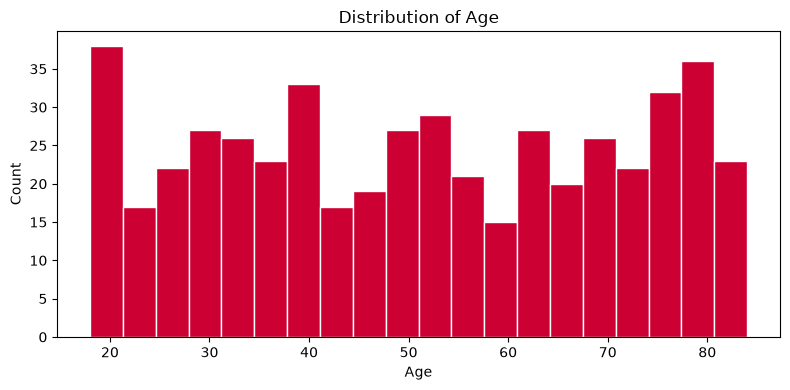

In [7]:
# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data['age'], bins=20, edgecolor='white', color='#CC0033')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Distribution of Age')
plt.tight_layout()
plt.show()

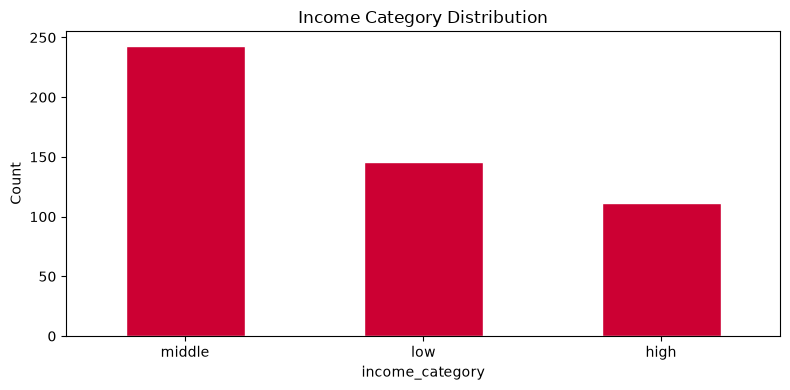

In [8]:
# Bar plot
fig, ax = plt.subplots(figsize=(8, 4))
data['income_category'].value_counts().plot(kind='bar', ax=ax, color='#CC0033', edgecolor='white')
ax.set_ylabel('Count')
ax.set_title('Income Category Distribution')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 6.5 Machine Learning Models

### Supervised Machine Learning: Logistic Regression for Binary Classification

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Prepare features (encode categoricals as dummy variables)
features = pd.get_dummies(data[['age', 'education_years', 'income_category', 'region']], drop_first=True)
target = data['supports_policy']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42, stratify=target
)
print(f"Training: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Training: 350 rows | Test: 150 rows


In [10]:
# Fit a logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"Test accuracy: {model.score(X_test, y_test):.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Oppose', 'Support']))

Test accuracy: 0.527

Classification Report:
              precision    recall  f1-score   support

      Oppose       0.40      0.15      0.22        66
     Support       0.55      0.82      0.66        84

    accuracy                           0.53       150
   macro avg       0.48      0.49      0.44       150
weighted avg       0.49      0.53      0.47       150



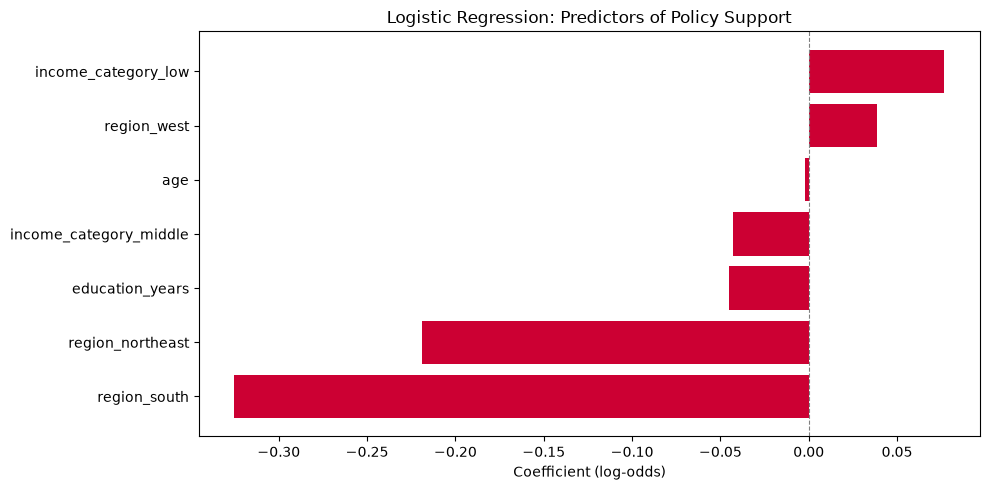

In [11]:
# Visualize coefficients
coefs = pd.DataFrame({
    'feature': features.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coefs['feature'], coefs['coefficient'], color='#CC0033')
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Logistic Regression: Predictors of Policy Support')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### Unsupervised Machine Learning: K-Means Clustering

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use only numeric features for clustering
numeric_features = data[['age', 'education_years']].copy()

# Standardize (important for distance-based methods)
scaler = StandardScaler()
scaled = scaler.fit_transform(numeric_features)

# K-means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(scaled)

print("Cluster sizes:")
print(data['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    169
1    157
2    174
Name: count, dtype: int64


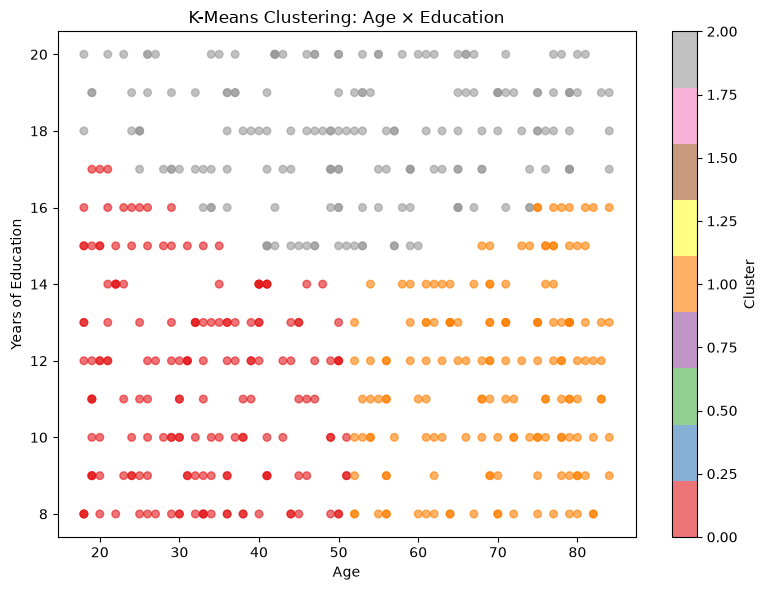

In [13]:
# Visualize the clusters
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(data['age'], data['education_years'],
                     c=data['cluster'], cmap='Set1', alpha=0.6, s=30)
ax.set_xlabel('Age')
ax.set_ylabel('Years of Education')
ax.set_title('K-Means Clustering: Age × Education')
plt.colorbar(scatter, label='Cluster', ax=ax)
plt.tight_layout()
plt.show()

In [14]:
# Profile the clusters
print("Cluster profiles:")
print(data.groupby('cluster')[['age', 'education_years']].mean().round(1))

Cluster profiles:
          age  education_years
cluster                       
0        32.2             11.4
1        69.8             11.5
2        52.7             17.9
